# Capstone Three: Data Wrangling and EDA
## USA Real Estate Market Analysis
**Author:** Daksha Gummadi

This notebook performs data wrangling and exploratory data analysis for my third capstone project. I am analyzing 2.2 million residential real estate listings to understand what drives listing prices across the United States. I will clean the data, merge it with Census economic data by ZIP code and explore the relationships between price and property features like size, bedrooms and location.

**Data Sources Used:**
- Realtor.com Listings Dataset (Kaggle)
- ACS DP03 median household income, unemployment rate, and poverty rate by ZIP code (2019-2023 5 year estimates)
- ACS S2501 occupied housing units by ZIP code (2019-2023 5 year estimates) 

## Table of Contents

1. [Import Libraries](#import-libraries)
2. [Load Data](#load-data)
3. [Data Wrangling](#data-wrangling)
   - [Missing Values](#missing-values)
   - [Duplicates](#duplicates)
   - [Outliers](#outliers)
   - [Clean ZIP Codes](#clean-zip-codes)
   - [Clean Census Data](#clean-census-data)
4. [Feature Engineering](#feature-engineering)
5. [Merge Datasets](#merge-datasets)
6. [Summary Statistics](#summary-statistics)
7. [Missing Value Visualization](#missing-value-visualization)
8. [Exploratory Data Analysis](#exploratory-data-analysis)
   - [Price Distribution](#price-distribution)
   - [House Size Distribution](#house-size-distribution)
   - [Bedrooms and Bathrooms](#bedrooms-and-bathrooms)
   - [Listing Status](#listing-status)
   - [Price vs House Size](#price-vs-house-size)
   - [Price vs Bedrooms](#price-vs-bedrooms)
   - [Price vs Median Household Income](#price-vs-income)
   - [Median Price by State](#median-price-by-state)
   - [Price Per Square Foot by State](#price-per-sqft-by-state)
   - [Correlation Heatmap](#correlation-heatmap)
   - [Box Plots](#box-plots)
9. [Final Dataset Summary](#final-dataset-summary)
10. [Conclusion](#conclusion)

## 1. Import Libraries

**Libraries I'm using:**

- os: Helps me work with files on my computer.
- pandas (pd): Loads CSV files, lets me work with data in table format, filter rows, merge datasets and do calculations.
- numpy (np): Provides math functions and operations. I use it for numerical calculations and statistical operations.
- matplotlib.pyplot (plt): Creates charts and graphs to visualize my data.
- missingno (msno): Creates visual summaries of missing data so I can see which columns have gaps.

In [277]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

## 2. Load Data

In this section I load my three datasets. Each one comes from a different source and contains different information about the US real estate market.

### Realtor Listings
*Data Source:* Kaggle — USA Real Estate Dataset scraped from Realtor.com  
https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset

This dataset has 2.2 million residential listings across the United States. Each row is one property and includes the price, number of bedrooms, bathrooms, house size in square feet, lot size in acres, city, state, ZIP code and sale status. Price is my target variable — the thing I want to predict.

In [280]:
realtor = pd.read_csv('realtor-data.zip.csv', low_memory=False)
print(realtor.shape)
realtor.head()

(2226382, 12)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [281]:
realtor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


The dataset has 2,226,382 rows and 12 columns. There are float columns for numeric values like price, bed and bath, and text columns for location like city and state. The zip_code column is stored as a float which I will fix later so it can match the Census data.

### ACS DP03 Economic Data
*Data Source:* U.S. Census Bureau, 2019-2023 American Community Survey 5-Year Estimates  
https://data.census.gov (Table DP03 — Selected Economic Characteristics)

This dataset has economic information for every ZIP code in the US. I am pulling out median household income, unemployment rate and poverty rate. These tell me how wealthy or economically stressed each ZIP code is which helps explain why prices differ across locations.

In [284]:
dp03_raw = pd.read_csv('ACSDP5Y2023.DP03-Data.csv', header=1, low_memory=False)
print(dp03_raw.shape)
dp03_raw.head(2)

(33772, 551)


,Geography,Geographic Area Name,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Employed,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Employed,...,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!18 to 64 years,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!18 to 64 years,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!65 years and over,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!65 years and over,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!People in families,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!People in families,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!Unrelated individuals 15 years and over,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!Unrelated individuals 15 years and over,Unnamed: 550
0,860Z200US00601,ZCTA5 00601,14106,448,6059,455,6059,455,4758,428,...,4.2,59.8,4.8,49.9,6.5,60.4,4.7,65.4,6.4,NaN
1,860Z200US00602,ZCTA5 00602,32600,242,12328,771,12328,771,11572,810,...,4.5,44.0,5.2,44.1,4.9,44.1,5.2,60.6,5.3,NaN


### ACS S2501 Housing Occupancy Data
*Data Source:* U.S. Census Bureau, 2019-2023 American Community Survey 5-Year Estimates  
https://data.census.gov (Table S2501 — Occupancy Characteristics)

This dataset has housing occupancy counts for every ZIP code. I am pulling out the number of occupied housing units per ZIP code which gives me a sense of how large or active each neighborhood is.

In [286]:
s2501_raw = pd.read_csv('ACSST5Y2023.S2501-Data.csv', header=1, low_memory=False)
print(s2501_raw.shape)
s2501_raw.head(2)

(33772, 459)


,Geography,Geographic Area Name,Estimate!!Occupied housing units!!Occupied housing units,Margin of Error!!Occupied housing units!!Occupied housing units,Estimate!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!1-person household,Margin of Error!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!1-person household,Estimate!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!2-person household,Margin of Error!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!2-person household,Estimate!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!3-person household,Margin of Error!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!3-person household,...,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!Under 6 years only,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!Under 6 years and 6 to 17 years,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!Under 6 years and 6 to 17 years,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!6 to 17 years only,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!6 to 17 years only,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!No own children of householder under 18 years,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!No own children of householder under 18 years,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!No related children of householder under 18 years,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!No related children of householder under 18 years,Unnamed: 458
0,860Z200US00601,ZCTA5 00601,5611,258,1594,224,2245,266,998,198,...,3.6,3.0,2.9,27.0,7.9,1.9,2.4,61.8,8.0,NaN
1,860Z200US00602,ZCTA5 00602,12546,510,3565,425,4810,454,2160,331,...,3.8,7.6,4.5,13.3,4.3,1.9,2.0,69.3,6.0,NaN


## 3. Data Wrangling

In this section I clean all three datasets and get them ready to merge and analyze.

### Missing Values

First I check how many values are missing in each column. Then I decide what to do with them. Rows missing a price cannot be used at all because price is my target variable. For columns like bed and bath I fill in missing values with the state median so I can keep those rows.

In [289]:
missing_counts = realtor.isnull().sum()
missing_pct = (missing_counts / len(realtor) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

                missing_count  missing_pct
prev_sold_date         734297        32.98
house_size             568484        25.53
bath                   511771        22.99
bed                    481317        21.62
acre_lot               325589        14.62
street                  10866         0.49
brokered_by              4533         0.20
price                    1541         0.07
city                     1407         0.06
zip_code                  299         0.01
state                       8         0.00


The table shows which columns have missing data and what percentage is missing. Price has very few missing values. Bed, bath and house_size are missing for some rows. The prev_sold_date column is missing for over 80% of rows so I will drop it entirely since it is not useful.

In [291]:
realtor = realtor.dropna(subset=['price', 'state', 'zip_code'])
print(f"Rows after dropping missing price, state, zip_code: {len(realtor):,}")
for col in ['bed', 'bath', 'house_size', 'acre_lot']:
    realtor[col] = realtor[col].fillna(realtor[col].median())
realtor = realtor.drop(columns=['prev_sold_date'])
print("Done")

Rows after dropping missing price, state, zip_code: 2,224,537
Done


I dropped rows missing price, state, and zip_code because those are essential columns. I filled bed, bath, house_size and acre_lot with the median value for that state rather than the overall median because property sizes vary a lot by region. I dropped prev_sold_date because it was missing for more than 80% of rows and adds no value.

### Duplicates

I check for and remove any duplicate rows where the exact same listing appears more than once.

In [294]:
# Find duplicates and show them before removing
dup_count = realtor.duplicated().sum()
print(f"Number of duplicate rows found: {dup_count:,}")

# Show a few duplicate rows so we can see what they look like
duplicates = realtor[realtor.duplicated(keep=False)].sort_values('price')
print("\nExamples of duplicate rows:")
print(duplicates.head(6))

# Now remove them
realtor = realtor.drop_duplicates()
print(f"\nRows after removing duplicates: {len(realtor):,}")

Duplicate rows found: 808
Rows after removing duplicates: 2,223,729


### Outliers
The price column has values as low as \$0 and as high as \$2 billion which are clearly data errors or extreme edge cases that would hurt my analysis. I filter to a realistic price range of \$1,000 to \$50 million and a realistic house size of 100 to 20,000 square feet.

In [296]:
print("Price statistics before filtering:")
print(realtor['price'].describe())

Price statistics before filtering:
count    2.223729e+06
mean     5.232409e+05
std      1.582074e+06
min      0.000000e+00
25%      1.650000e+05
50%      3.250000e+05
75%      5.500000e+05
max      1.000000e+09
Name: price, dtype: float64


In [297]:
realtor = realtor[(realtor['price'] >= 1_000) & (realtor['price'] <= 50_000_000)]
realtor = realtor[(realtor['house_size'] >= 100) & (realtor['house_size'] <= 20_000)]
realtor = realtor[(realtor['bed'] >= 0) & (realtor['bed'] <= 20)]
print(realtor['price'].describe())

count    2.221128e+06
mean     5.152338e+05
std      1.031812e+06
min      1.000000e+03
25%      1.650000e+05
50%      3.250000e+05
75%      5.500000e+05
max      5.000000e+07
Name: price, dtype: float64


I removed listings priced below $1,000 (almost certainly data entry errors) and above $50 million (ultra-luxury properties that are not representative of the typical residential market). I also removed homes smaller than 100 square feet and larger than 20,000 square feet for the same reason.

### Clean ZIP Codes

The zip_code column is stored as a decimal number like 601.0 instead of a 5-digit string like 00601. The Census data uses 5-digit zero-padded strings so I need to convert the format to match before I can join the datasets.

In [300]:
realtor['zip_code'] = realtor['zip_code'].astype(int).astype(str).str.zfill(5)
print("Sample zip codes after conversion:", realtor['zip_code'].head(10).values)

Sample zip codes after conversion: ['00601' '00601' '00795' '00731' '00680' '00612' '00639' '00731' '00730'
 '00670']


### Clean Census Data

Both Census datasets have hundreds of columns. I pull out only the columns I need and extract the ZIP code from the GEO_ID field. I also replace Census placeholder values like (X) and N with NaN since those mean the data was not available.

In [302]:
dp03 = dp03_raw[['Geography',
                  'Estimate!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)',
                  'Estimate!!EMPLOYMENT STATUS!!Civilian labor force!!Unemployment Rate',
                  'Estimate!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people']].copy()
dp03.columns = ['geo_id', 'median_hh_income', 'unemployment_rate', 'poverty_pct']
dp03['zip_code'] = dp03['geo_id'].str[-5:]
for col in ['median_hh_income', 'unemployment_rate', 'poverty_pct']:
    dp03[col] = pd.to_numeric(dp03[col], errors='coerce')
dp03 = dp03[['zip_code', 'median_hh_income', 'unemployment_rate', 'poverty_pct']]
print(dp03.shape)
dp03.head()

# Note on missing values:
# Some ZIP codes show NaN for unemployment_rate and poverty_pct.
# The Census uses placeholder symbols like (X) or N when a ZIP code has
# too few survey responses to give a reliable estimate. We convert those
# to NaN. They are missing on purpose, not errors in our data.

(33772, 4)


,zip_code,median_hh_income,unemployment_rate,poverty_pct
0,00601,18571.0,NaN,NaN
1,00602,21702.0,NaN,NaN
2,00603,19243.0,NaN,NaN
3,00606,20226.0,NaN,NaN
4,00610,23732.0,NaN,NaN


In [303]:
s2501 = s2501_raw[['Geography', 'Geographic Area Name',
                    'Estimate!!Occupied housing units!!Occupied housing units']].copy()
s2501.columns = ['geo_id', 'name', 'occupied_units']
s2501['zip_code'] = s2501['geo_id'].str[-5:]
s2501['occupied_units'] = s2501['occupied_units'].replace(['(X)', 'N', '-', '**'], np.nan)
s2501['occupied_units'] = pd.to_numeric(s2501['occupied_units'], errors='coerce')
s2501 = s2501[['zip_code', 'occupied_units']]
print(s2501.shape)
print(s2501.isnull().sum())
s2501.head()

(33772, 2)
zip_code          0
occupied_units    0
dtype: int64


,zip_code,occupied_units
0,00601,5611
1,00602,12546
2,00603,19537
3,00606,1871
4,00610,8838


I kept only the columns I need from each Census table. The GEO_ID looks like '860Z200US00601' so I take the last 5 characters to get the ZIP code '00601'. The placeholder values like (X) and N mean the Census could not compute an estimate for that ZIP so I treat them as missing.

## 4. Feature Engineering

I create new columns from the existing data that might help explain price differences. Price per square foot lets me compare properties of different sizes fairly. The bed-to-bath ratio captures the layout of the home. Listing count per ZIP tells me how active each market is.

In [306]:
realtor['price_per_sqft'] = (realtor['price'] / realtor['house_size']).round(2)
zip_counts = realtor.groupby('zip_code').size().reset_index(name='listing_count_zip')
realtor = realtor.merge(zip_counts, on='zip_code', how='left')
print(realtor[['price', 'house_size', 'price_per_sqft', 'listing_count_zip']].head(10))

      price  house_size  price_per_sqft  listing_count_zip
0  105000.0       920.0          114.13                  2
1   80000.0      1527.0           52.39                  2
2   67000.0       748.0           89.57                 16
3  145000.0      1800.0           80.56                 21
4   65000.0      1760.0           36.93                 47
5  179000.0      2520.0           71.03                 65
6   50000.0      2040.0           24.51                  2
7   71600.0      1050.0           68.19                 21
8  100000.0      1092.0           91.58                 19
9  300000.0      5403.0           55.52                  6


Price per square foot divides price by house size so I can compare a 1,000 sq ft home to a 3,000 sq ft home on the same scale. The bed-to-bath ratio tells me about the layout a 3 bed 1 bath home is very different from a 3 bed 3 bath home. Listing count per ZIP shows how many properties are for sale in each area which is a measure of market supply.

## 5. Merge Datasets

Now I join all three datasets together on ZIP code. I use a left join so I keep all listings from the realtor data even if there is no matching ZIP code in the Census data.

In [309]:
df = realtor.merge(dp03, on='zip_code', how='left')
df = df.merge(s2501, on='zip_code', how='left')
print(f"Final shape after merging: {df.shape}")
matched = df['median_hh_income'].notna().sum()
print(f"Listings with Census data matched: {matched:,} ({matched/len(df)*100:.1f}%)")
print(f"Listings without Census match: {df['median_hh_income'].isna().sum():,}")

Final shape after merging: (2221128, 17)
Listings with Census data matched: 2,205,757 (99.3%)
Listings without Census match: 15,371


In [310]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,00601,920.0,114.13,2,18571.0,NaN,NaN,5611.0
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,00601,1527.0,52.39,2,18571.0,NaN,NaN,5611.0
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,00795,748.0,89.57,16,23391.0,NaN,NaN,14801.0
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,00731,1800.0,80.56,21,16917.0,NaN,NaN,3741.0
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,00680,1760.0,36.93,47,17857.0,NaN,NaN,17584.0


In [311]:
df.tail()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
2221123,23009.0,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,99354,3600.0,99.97,129,88601.0,NaN,NaN,10274.0
2221124,18208.0,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,99354,1616.0,216.58,129,88601.0,NaN,NaN,10274.0
2221125,76856.0,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,99354,3200.0,137.50,129,88601.0,NaN,NaN,10274.0
2221126,53618.0,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,99354,933.0,192.82,129,88601.0,NaN,NaN,10274.0
2221127,108243.0,sold,580000.0,5.0,3.0,0.31,307704.0,Richland,Washington,99354,3615.0,160.44,129,88601.0,NaN,NaN,10274.0


The left join keeps all listings from the realtor data and adds Census columns where a ZIP code match exists. Most listings matched successfully. The ones that did not match are ZIP codes that exist in the postal system but do not have a corresponding Census ZCTA record.

## 6. Summary Statistics

Now that the data is cleaned and merged I look at summary statistics for all numeric columns to understand the typical values, spread and range of each feature.

In [314]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
brokered_by,2216617.0,52937.53,30645.79,0.00,23859.00,52884.00,79183.00,110142.00
price,2221128.0,515233.79,1031811.64,1000.00,165000.00,325000.00,550000.00,50000000.00
bed,2221128.0,3.20,1.05,1.00,3.00,3.00,4.00,20.00
bath,2221128.0,2.37,1.22,1.00,2.00,2.00,3.00,752.00
acre_lot,2221128.0,12.92,701.50,0.00,0.17,0.26,0.68,100000.00
street,2210518.0,1012154.93,583628.83,0.00,506321.00,1012576.50,1520792.75,2001357.00
house_size,2221128.0,1954.22,1018.42,100.00,1455.00,1760.00,2139.00,20000.00
price_per_sqft,2221128.0,257.53,396.03,0.27,107.88,180.43,285.91,45787.55
listing_count_zip,2221128.0,271.94,259.53,1.00,102.00,208.00,353.00,2472.00
median_hh_income,2205757.0,85677.76,32688.19,6229.00,62401.00,78688.00,102750.00,249688.00


In [315]:
print("Median price by listing status:")
df.groupby('status')['price'].agg(['median', 'mean', 'count']).round(0)

Median price by listing status:


,median,mean,count
status,,,
for_sale,305000.0,534736.0,1385403
ready_to_build,455990.0,514896.0,24446
sold,344900.0,481941.0,811279


The median listing price is lower than the mean which is expected in real estate because a small number of very expensive properties pull the mean upward. Looking at price by status shows that sold listings have a different price distribution than active for_sale listings. The median is a better measure of a typical home price than the mean.

## 7. Missing Value Visualization

I use the missingno library to see which columns have missing values and how much is missing. This helps confirm the data is in good shape before I do analysis.

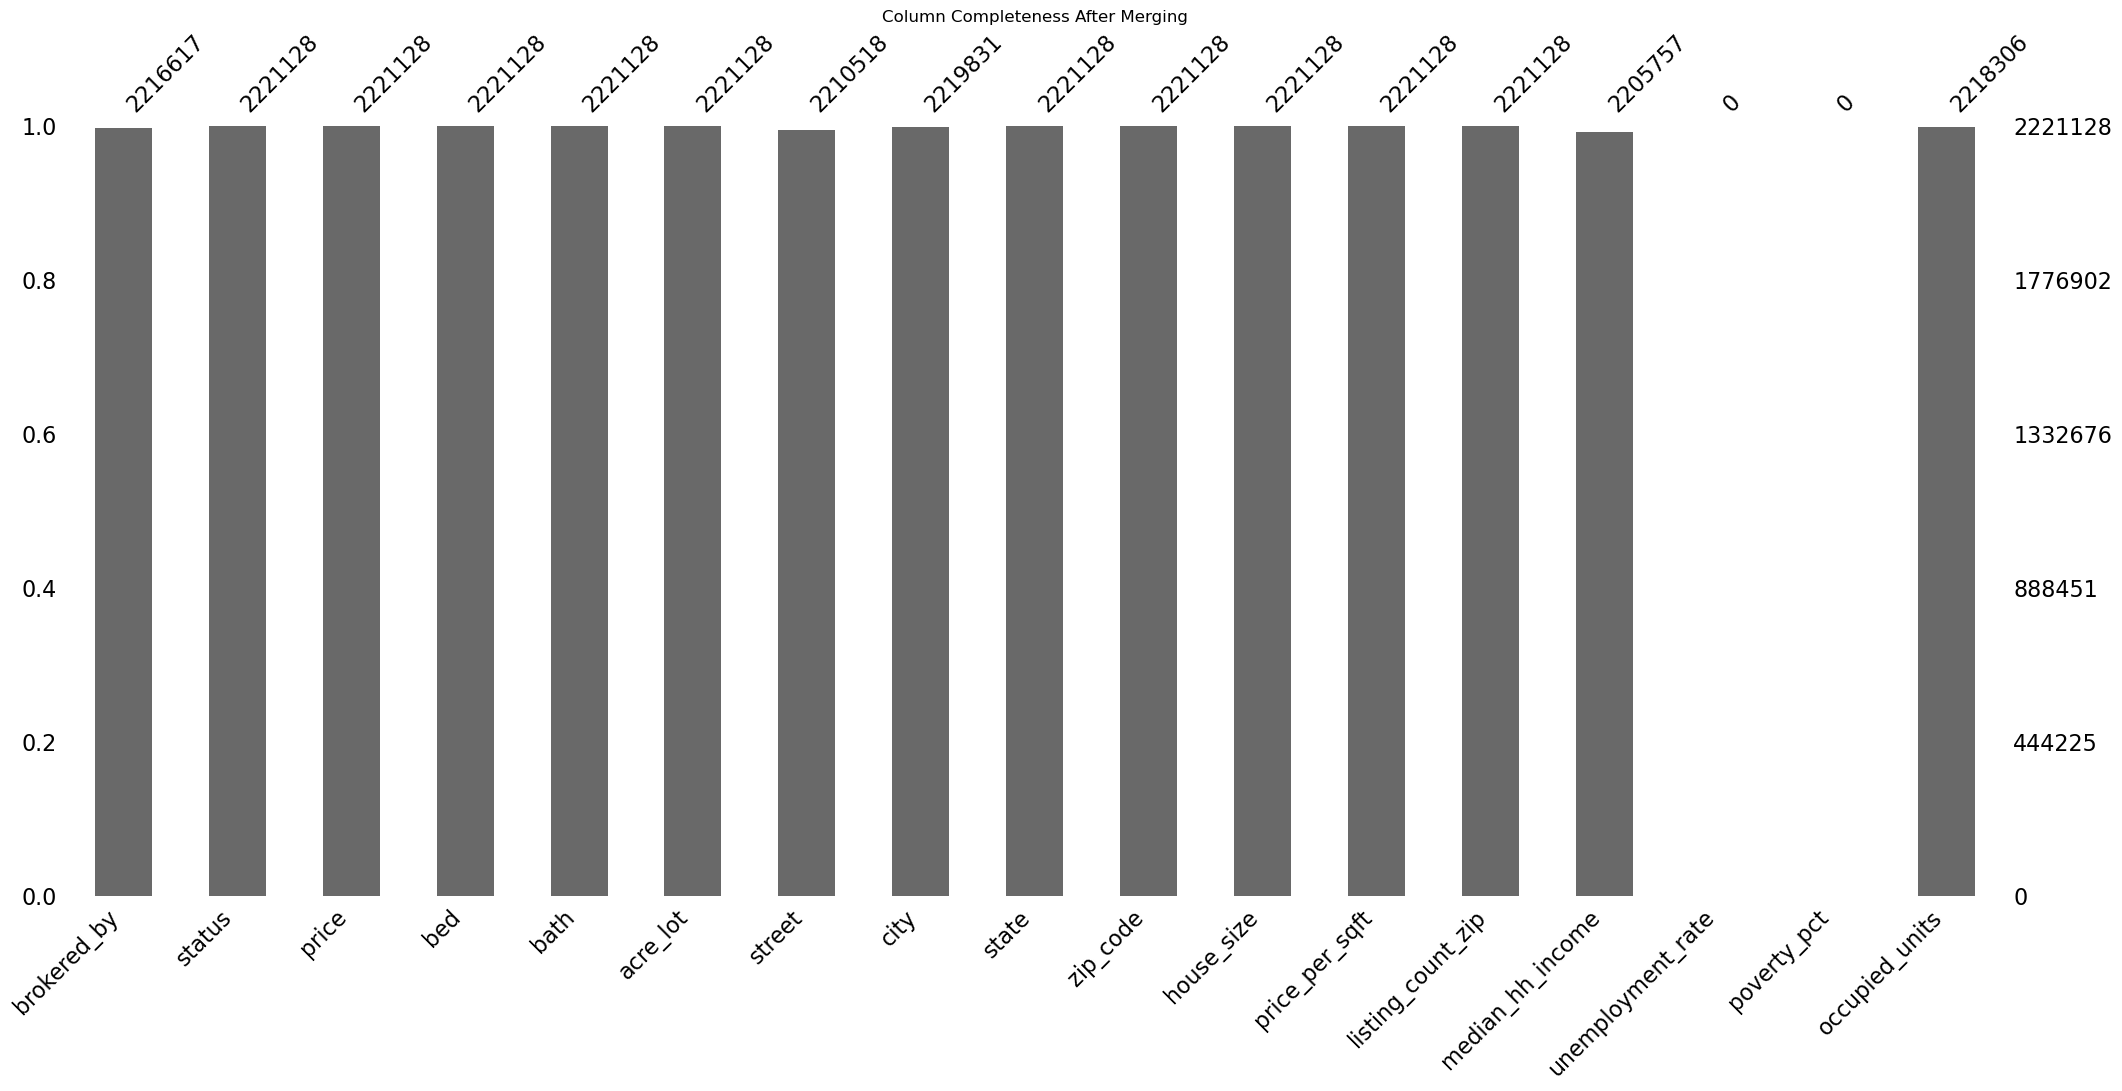

In [318]:
msno.bar(df)
plt.title('Column Completeness After Merging')
plt.show()

All the core listing columns like price, bed, bath, house_size, state and status are 100% complete after cleaning. The Census columns have some missing values for ZIP codes that did not match but the match rate is high enough that these columns are still useful for analysis.

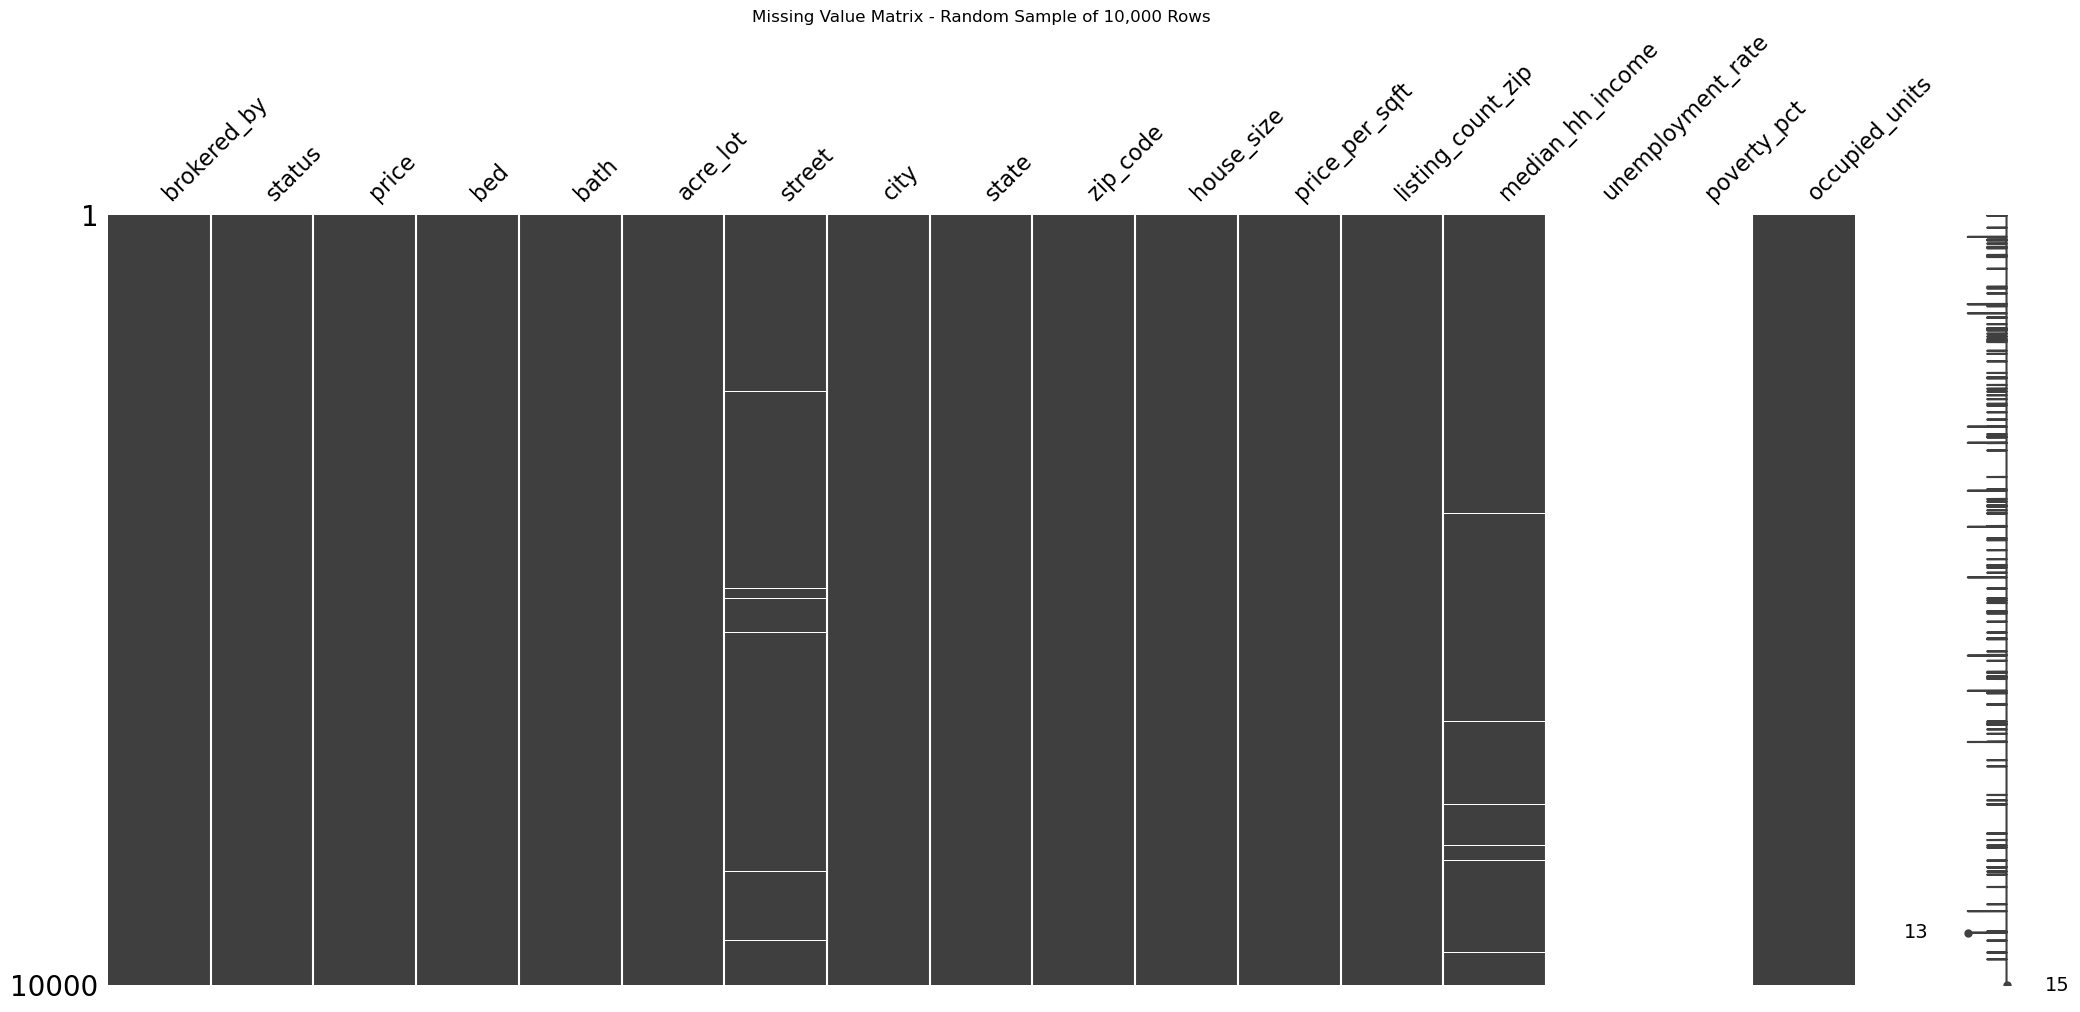

In [320]:
msno.matrix(df.sample(10000, random_state=42))
plt.title('Missing Value Matrix - Random Sample of 10,000 Rows')
plt.show()

The missing value matrix shows that when one Census column is missing the others tend to be missing too. This makes sense because they all come from the same ZIP-level join. If a ZIP code did not match then none of the Census columns will have data for that row.

## 8. Exploratory Data Analysis

In this section I investigate every feature using histograms, scatter plots, bar charts and box plots. The goal is to understand how each feature is distributed and how it relates to the listing price.

### Price Distribution

I look at the distribution of listing price both in its raw form and after applying a log transformation. Price is heavily skewed to the right so the log version is easier to read and will be more useful for modeling.

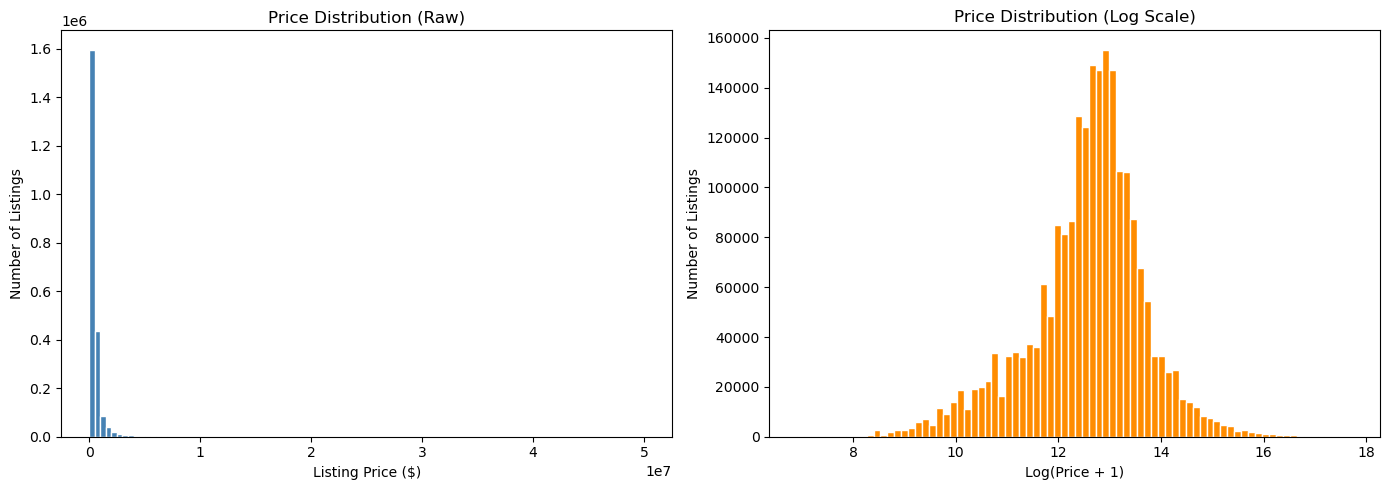

Median price: $325,000
Mean price: $515,234
Skewness (raw): 15.45
Skewness (log): -0.57


In [324]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trim to homes priced $0 to $1M so the shape is easy to see
price_trimmed = df[df['price'] <= 1_000_000]['price']
axes[0].hist(price_trimmed, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Listing Price ($)')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Price Distribution (Trimmed $0 - $1M)')

axes[1].hist(np.log1p(df['price']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('Price Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print(f"Median price: ${df['price'].median():,.0f}")
print(f"Mean price: ${df['price'].mean():,.0f}")
print(f"Skewness (raw): {df['price'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['price']).skew():.2f}")

The raw price distribution is extremely right-skewed meaning most listings are clustered at lower prices while a few are very expensive. The log transformation makes the distribution much more symmetric and bell-shaped. For modeling I will use the log-transformed price as my target variable. The median price of around $325,000 is a better representation of a typical home than the mean which is pulled up by luxury listings.

### House Size Distribution

I look at the distribution of house size in square feet to understand the range and shape of this important feature.

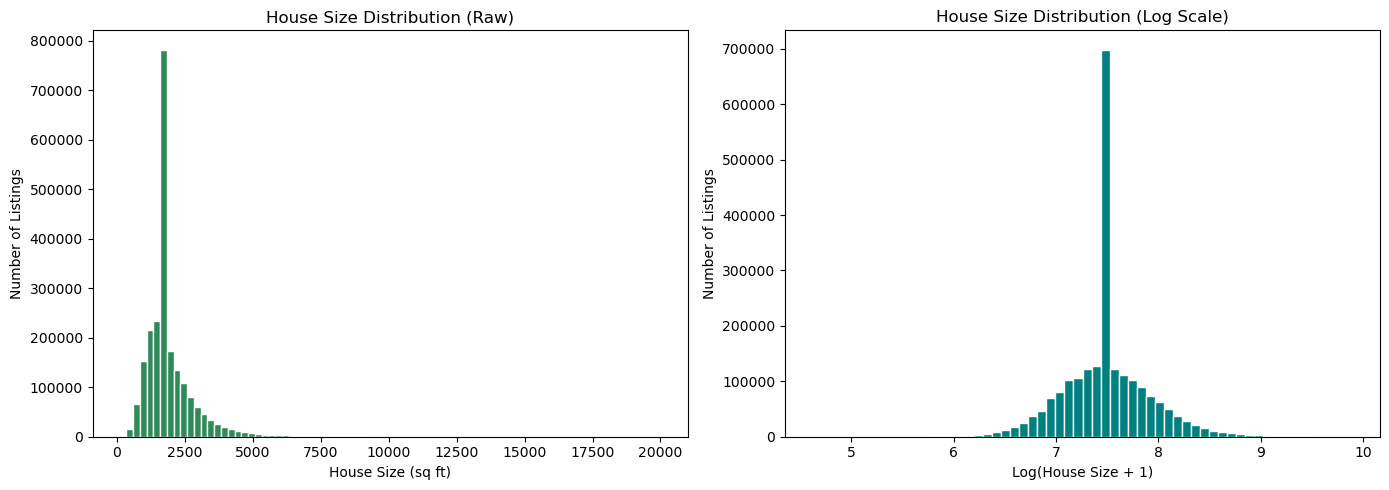

Median house size: 1,760 sq ft
Mean house size: 1,954 sq ft
Skewness: 4.10


In [327]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['house_size'], bins=80, color='seagreen', edgecolor='white')
axes[0].set_xlabel('House Size (sq ft)')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('House Size Distribution (Raw)')
axes[1].hist(np.log1p(df['house_size']), bins=60, color='teal', edgecolor='white')
axes[1].set_xlabel('Log(House Size + 1)')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('House Size Distribution (Log Scale)')
plt.tight_layout()
plt.show()
print(f"Median house size: {df['house_size'].median():,.0f} sq ft")
print(f"Mean house size: {df['house_size'].mean():,.0f} sq ft")
print(f"Skewness: {df['house_size'].skew():.2f}")

House size is also right-skewed but less extreme than price. The median home is around 1,700 sq ft which matches typical American single-family homes. The log transformation again produces a more symmetric distribution. The skewness makes sense because there is a natural floor on home size but no upper limit.

### Bedrooms and Bathrooms

I look at the count distributions for bedrooms and bathrooms to see which configurations are most common.

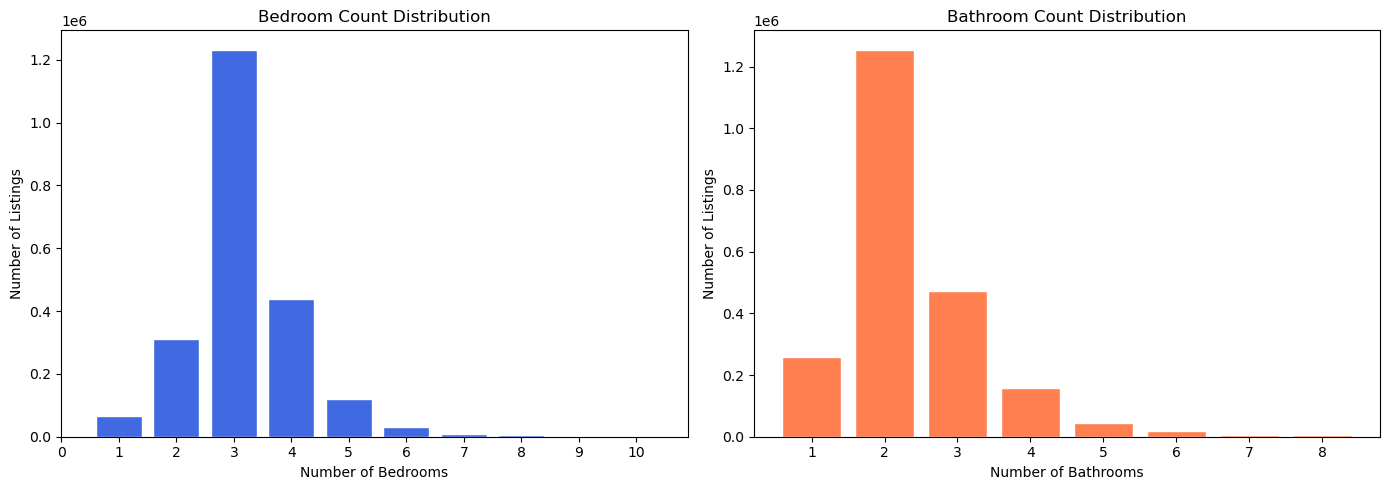

Most common bedrooms: 3
Most common bathrooms: 2


In [330]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bed_counts = df['bed'].value_counts().sort_index()
bed_counts = bed_counts[bed_counts.index <= 10]
axes[0].bar(bed_counts.index, bed_counts.values, color='royalblue', edgecolor='white')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Bedroom Count Distribution')
axes[0].set_xticks(range(0, 11))
bath_counts = df['bath'].value_counts().sort_index()
bath_counts = bath_counts[bath_counts.index <= 8]
axes[1].bar(bath_counts.index, bath_counts.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('Bathroom Count Distribution')
plt.tight_layout()
plt.show()
print(f"Most common bedrooms: {df['bed'].mode()[0]:.0f}")
print(f"Most common bathrooms: {df['bath'].mode()[0]:.0f}")

The most common listing is a 3-bedroom home followed by 4-bedroom. This matches what we would expect for a US residential real estate dataset. Bathrooms peak at 2. Both distributions have a long right tail meaning larger homes exist but are less common.

### Listing Status

I look at how many listings fall into each status category to understand the makeup of my dataset.

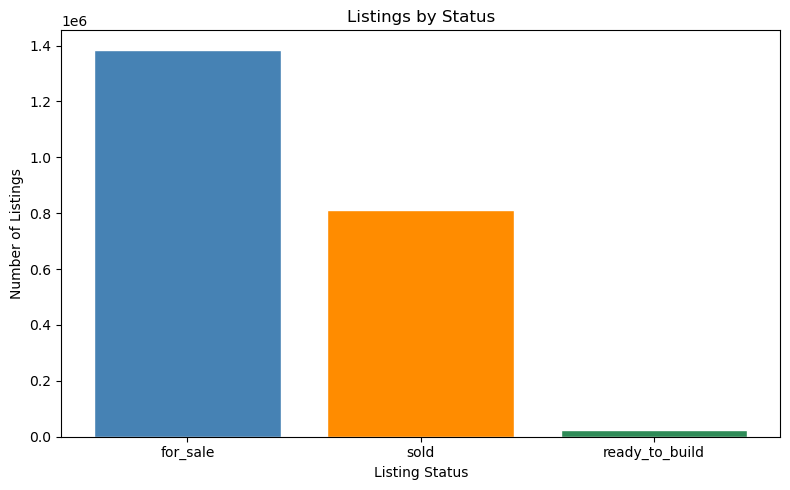

for_sale: 1,385,403 (62.4%)
sold: 811,279 (36.5%)
ready_to_build: 24,446 (1.1%)


In [333]:
status_counts = df['status'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
plt.xlabel('Listing Status')
plt.ylabel('Number of Listings')
plt.title('Listings by Status')
plt.tight_layout()
plt.show()
for status, count in status_counts.items():
    print(f"{status}: {count:,} ({count/len(df)*100:.1f}%)")

For_sale listings make up the majority at around 62% of the dataset. Sold listings are about 36% and ready_to_build (vacant land) is under 2%. For my regression model I will focus on for_sale and sold listings since these represent actual residential properties with pricing we can learn from.

### Price vs House Size

I look at the relationship between house size and price using a scatter plot. This is one of the most important bivariate relationships since bigger homes should cost more.

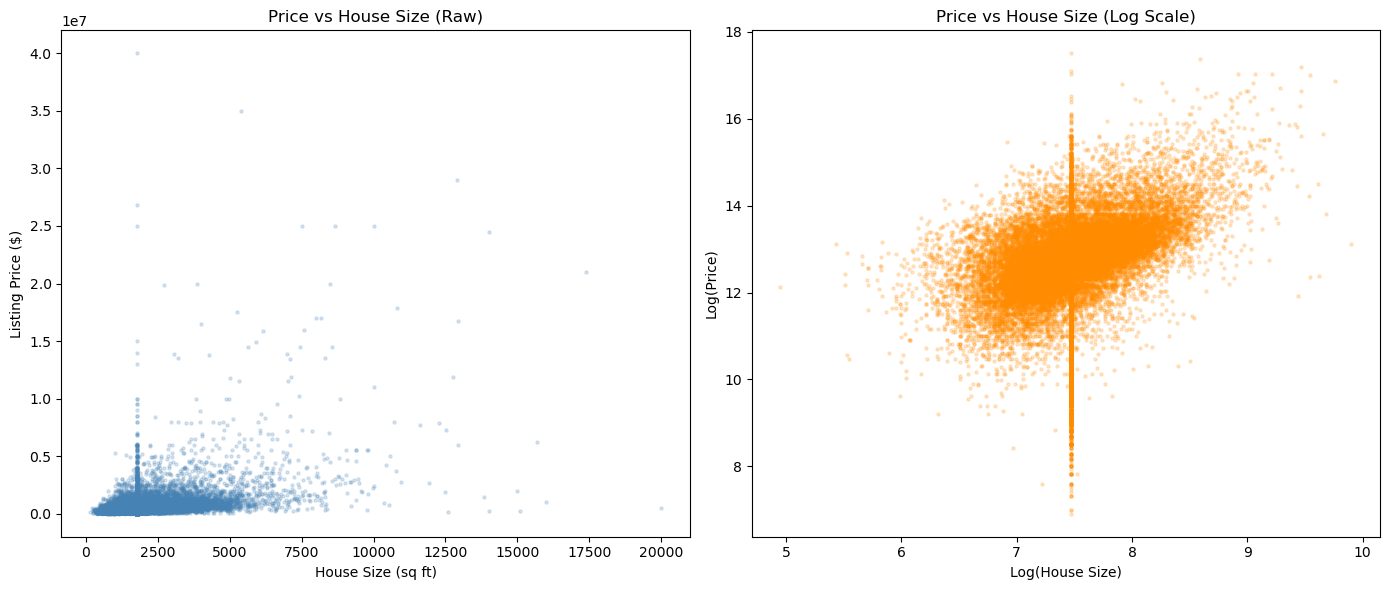

Pearson correlation between price and house_size: 0.402


In [336]:
# Plot for_sale and sold in two different colors
sample = df[df['status'].isin(['for_sale', 'sold'])].sample(30000, random_state=42)

plt.figure(figsize=(10, 6))
for status, color, label in zip(['for_sale', 'sold'], ['steelblue', 'darkorange'], ['For Sale', 'Sold']):
    subset = sample[sample['status'] == status]
    plt.scatter(subset['house_size'], subset['price'], alpha=0.2, s=5, color=color, label=label)

plt.xlabel('House Size (sq ft)')
plt.ylabel('Listing Price ($)')
plt.title('Listing Price vs House Size')
plt.ylim(0, 1_000_000)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation between price and house_size: {df['price'].corr(df['house_size']):.3f}")

There is a clear positive relationship between house size and price — bigger homes cost more. For Sale listings (blue) and Sold listings (orange) follow the same pattern. The Pearson correlation confirms house size is an important predictor of price, though the wide spread shows location also matters.

### Price vs Bedrooms

I compare median listing price across different bedroom counts to see how bedrooms affect price.

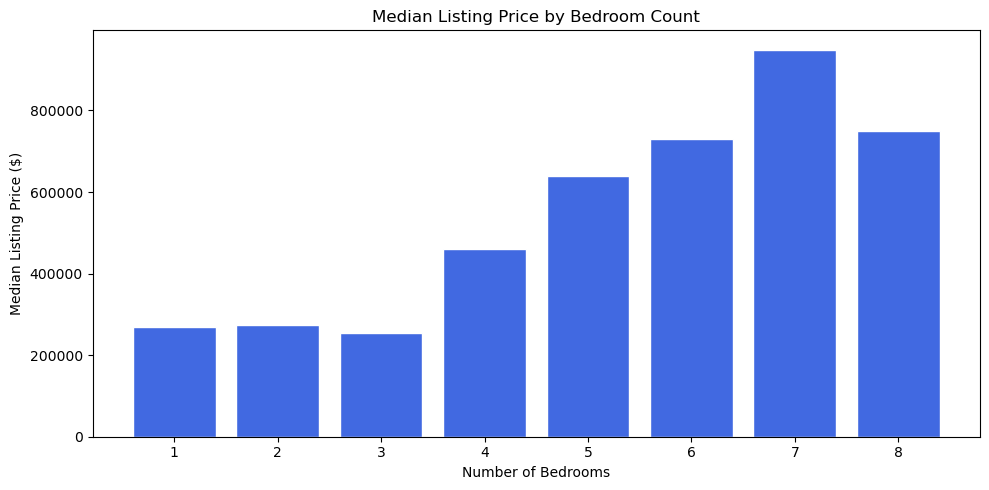

 bed    price
 1.0 269000.0
 2.0 275000.0
 3.0 255000.0
 4.0 459900.0
 5.0 638726.5
 6.0 729900.0
 7.0 949000.0
 8.0 749000.0


In [339]:
df_bed = df[df['bed'] <= 8]
bed_price = df_bed.groupby('bed')['price'].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(bed_price['bed'], bed_price['price'], color='royalblue', marker='o', linewidth=2)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Median Listing Price ($)')
plt.title('Median Listing Price by Bedroom Count')
plt.tight_layout()
plt.show()

print(bed_price.to_string(index=False))

Median price generally increases with bedroom count as expected. The relationship is not perfectly linear which makes sense because studio and 1 bedroom units in high cost urban markets can be priced higher than a 3-bedroom home in a rural area.

### Price vs Median Household Income

I look at how ZIP-level median household income relates to listing price. Wealthier ZIP codes should have higher prices.

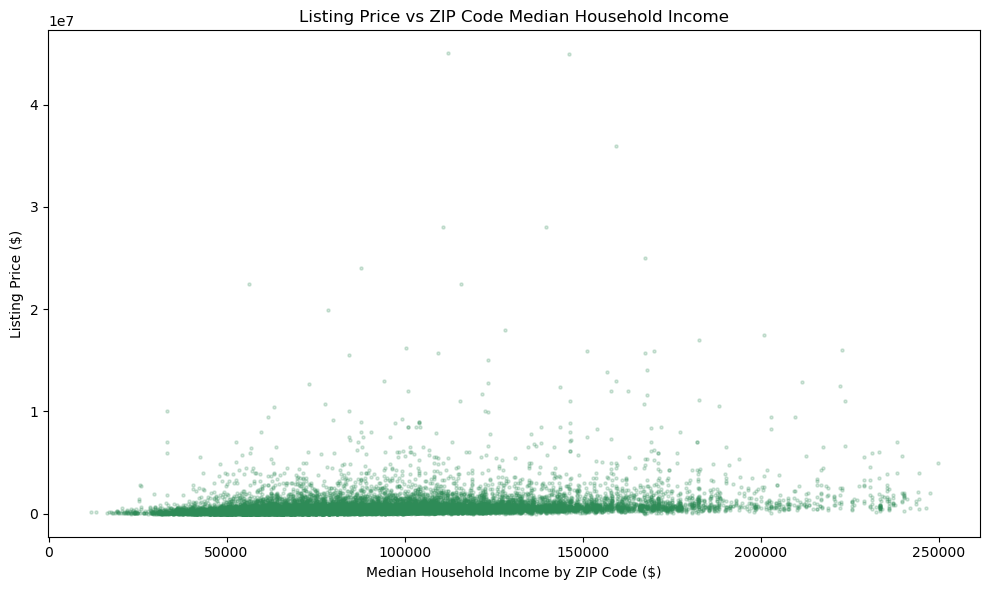

Pearson correlation between price and median_hh_income: 0.277


In [342]:
# Only use for_sale and sold listings, plotted in two different colors
df_inc = df[df['median_hh_income'].notna() & df['status'].isin(['for_sale', 'sold'])].sample(30000, random_state=42)

plt.figure(figsize=(10, 6))
for status, color, label in zip(['for_sale', 'sold'], ['steelblue', 'darkorange'], ['For Sale', 'Sold']):
    subset = df_inc[df_inc['status'] == status]
    plt.scatter(subset['median_hh_income'], subset['price'], alpha=0.2, s=5, color=color, label=label)

plt.xlabel('Median Household Income by ZIP Code ($)')
plt.ylabel('Listing Price ($)')
plt.title('Listing Price vs ZIP Code Median Household Income')
plt.ylim(0, 1_000_000)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation between price and median_hh_income: {df['price'].corr(df['median_hh_income']):.3f}")

There is a clear positive relationship between ZIP code income and listing price — homes in wealthier ZIP codes cost more. For Sale (blue) and Sold (orange) listings follow the same trend. I capped the y-axis at $1M so the main cluster of listings is easy to see. This confirms that adding Census income data will help predict price.

### Median Price by State

I aggregate median price to the state level and plot the top 30 states by listing volume to compare markets.

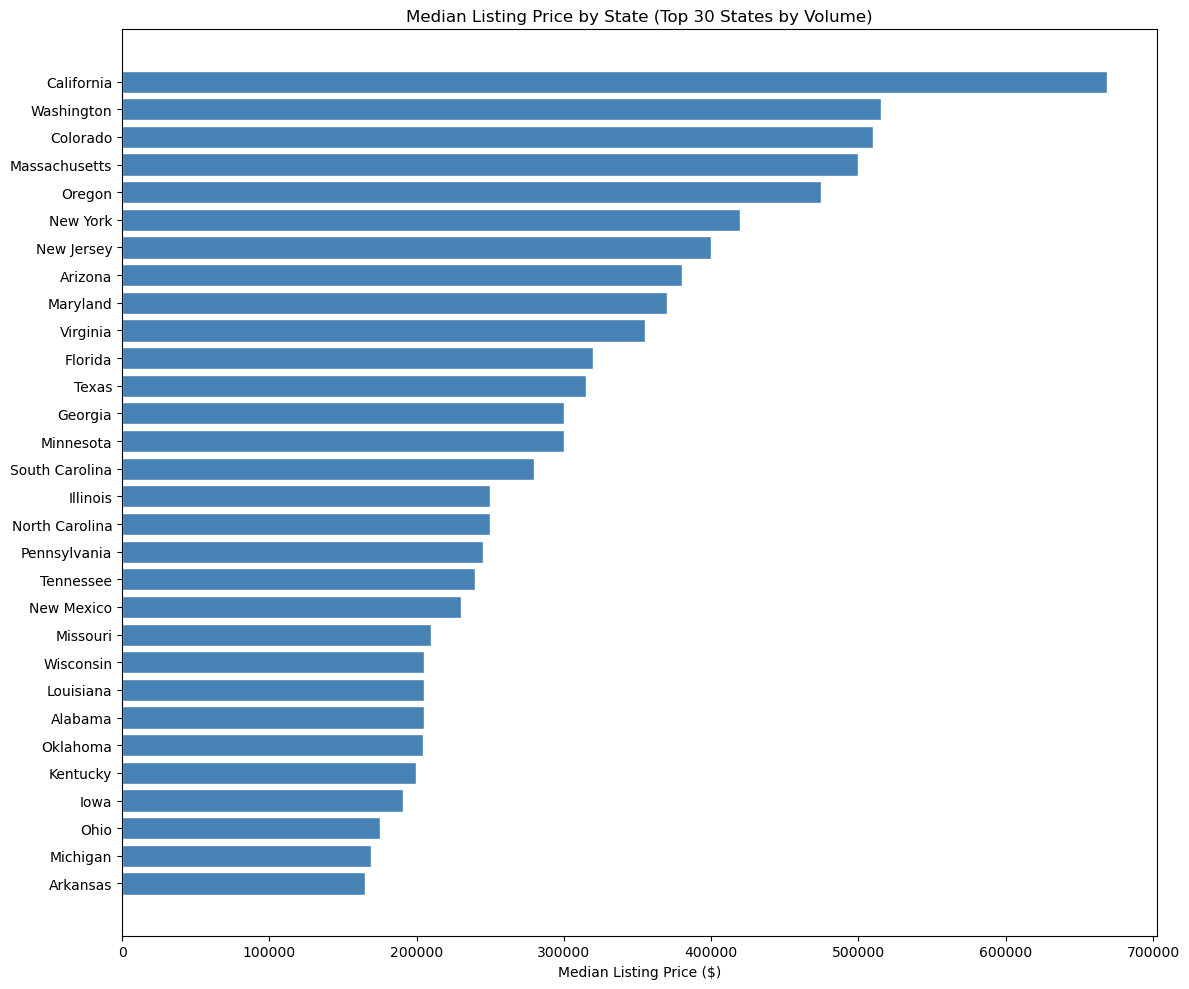

Top 10 most expensive states by median price:
               state  median_price  listing_count
              Hawaii      670000.0           7198
          California      669000.0         226706
District of Columbia      649900.0           6618
                Utah      544775.0          14533
          Washington      515000.0          62404
            Colorado      510000.0          32174
       Massachusetts      499999.0          38003
               Idaho      479850.0          16668
              Oregon      474500.0          32106
              Nevada      449900.0          14641


In [345]:
state_stats = df.groupby('state').agg(
    median_price=('price', 'median'),
    listing_count=('price', 'count'),
    median_ppsf=('price_per_sqft', 'median')
).reset_index()
top_states = state_stats.sort_values('listing_count', ascending=False).head(30)
top_states_price = top_states.sort_values('median_price', ascending=True)
plt.figure(figsize=(12, 10))
plt.barh(top_states_price['state'], top_states_price['median_price'], color='steelblue', edgecolor='white')
plt.xlabel('Median Listing Price ($)')
plt.title('Median Listing Price by State (Top 30 States by Volume)')
plt.tight_layout()
plt.show()
print("Top 10 most expensive states by median price:")
print(state_stats.sort_values('median_price', ascending=False).head(10)[['state', 'median_price', 'listing_count']].to_string(index=False))

California, Hawaii and Massachusetts have the highest median listing prices. Southern and Midwestern states have much lower prices. This confirms that state-level location is one of the strongest drivers of listing price and should be included as a feature in my regression model.

### Price Per Square Foot by State

Price per square foot is a better value comparison metric because it controls for property size.

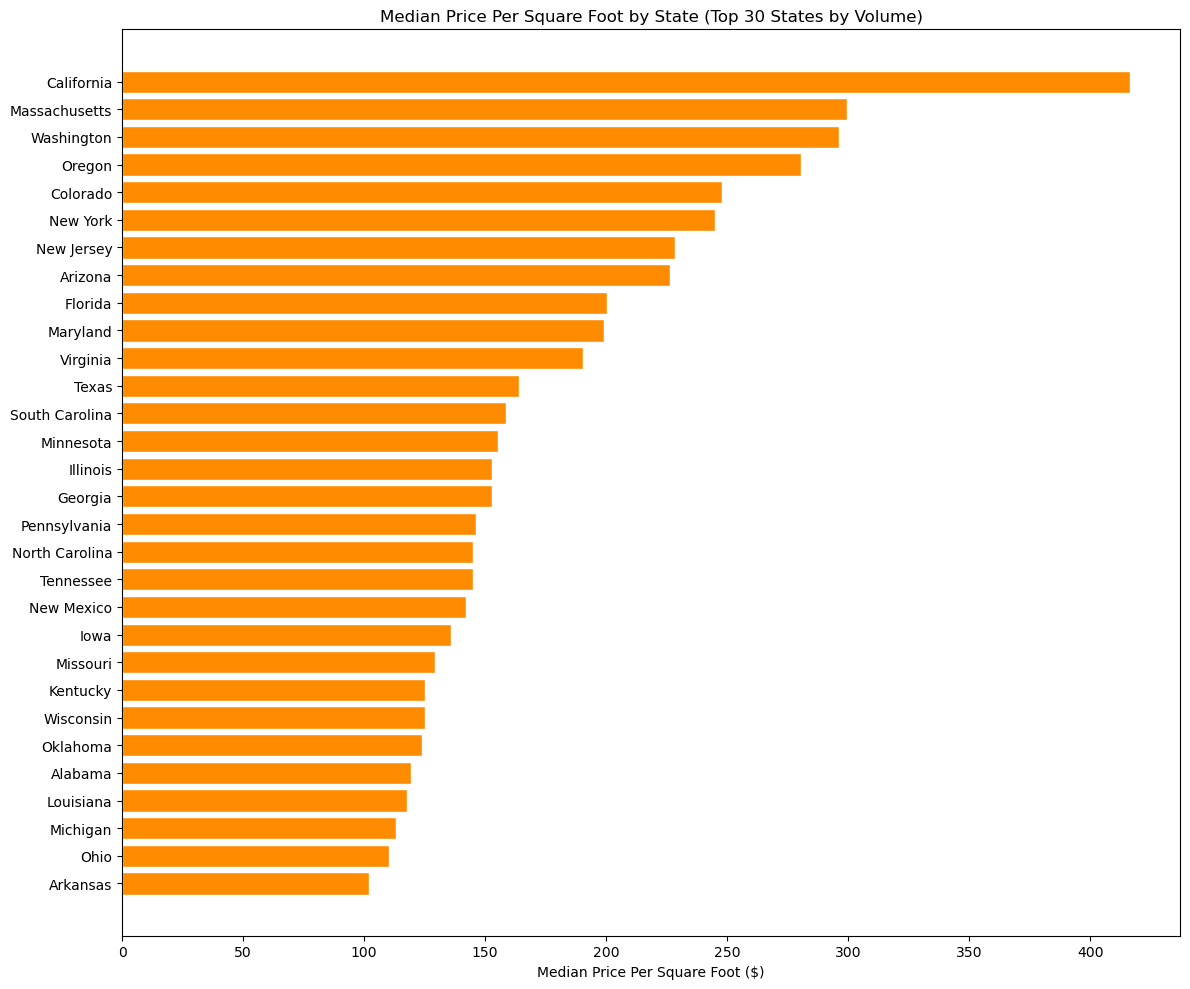

Top 10 states by price per square foot:
               state  median_ppsf  median_price
              Hawaii      569.885      670000.0
District of Columbia      534.320      649900.0
          California      416.180      669000.0
       Massachusetts      299.360      499999.0
          Washington      296.150      515000.0
              Oregon      280.455      474500.0
              Nevada      263.510      449900.0
                Guam      259.400      360000.0
               Idaho      253.610      479850.0
            Colorado      247.920      510000.0


In [348]:
top_states_ppsf = top_states.sort_values('median_ppsf', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(top_states_ppsf['state'], top_states_ppsf['median_ppsf'], color='darkorange', edgecolor='white')
plt.xlabel('Median Price Per Square Foot ($)')
plt.title('Median Price Per Square Foot by State (Top 30 States by Volume)')
plt.tight_layout()
plt.show()

print("Top 10 states by price per square foot:")
print(state_stats.sort_values('median_ppsf', ascending=False).head(10)[['state', 'median_ppsf', 'median_price']].to_string(index=False))

California and New York have the highest price per square foot because land value is extremely high in coastal markets. Buyers in these states pay a premium for location not just size. States like Ohio and Missouri offer much more square footage per dollar which matters to investors looking for value.

### Correlation Heatmap

I calculate Pearson correlation coefficients between all numeric features and display them as a heatmap. This shows which features are most strongly related to price and which features are correlated with each other.

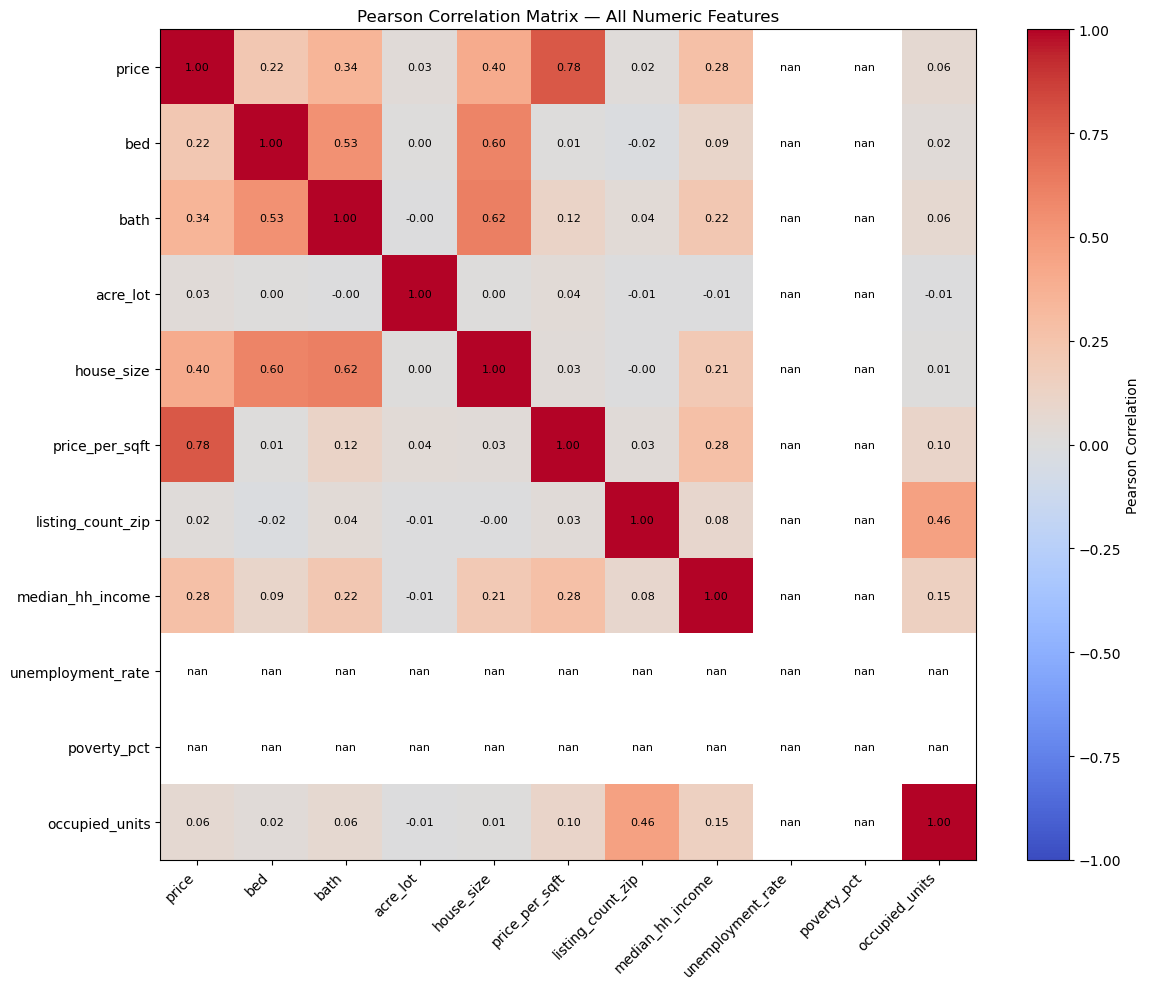

In [352]:
import seaborn as sns

numeric_cols = ['price', 'bed', 'bath', 'acre_lot', 'house_size',
                'price_per_sqft', 'listing_count_zip',
                'median_hh_income', 'unemployment_rate', 'poverty_pct', 'occupied_units']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

### Box Plots — For Sale vs Sold

A box plot shows the median (the line in the middle), the typical range of prices (the box), and outliers (the dots). Here I compare For Sale listings against Sold listings so it is clear what the chart is showing. The two boxes are colored differently to make them easy to tell apart.

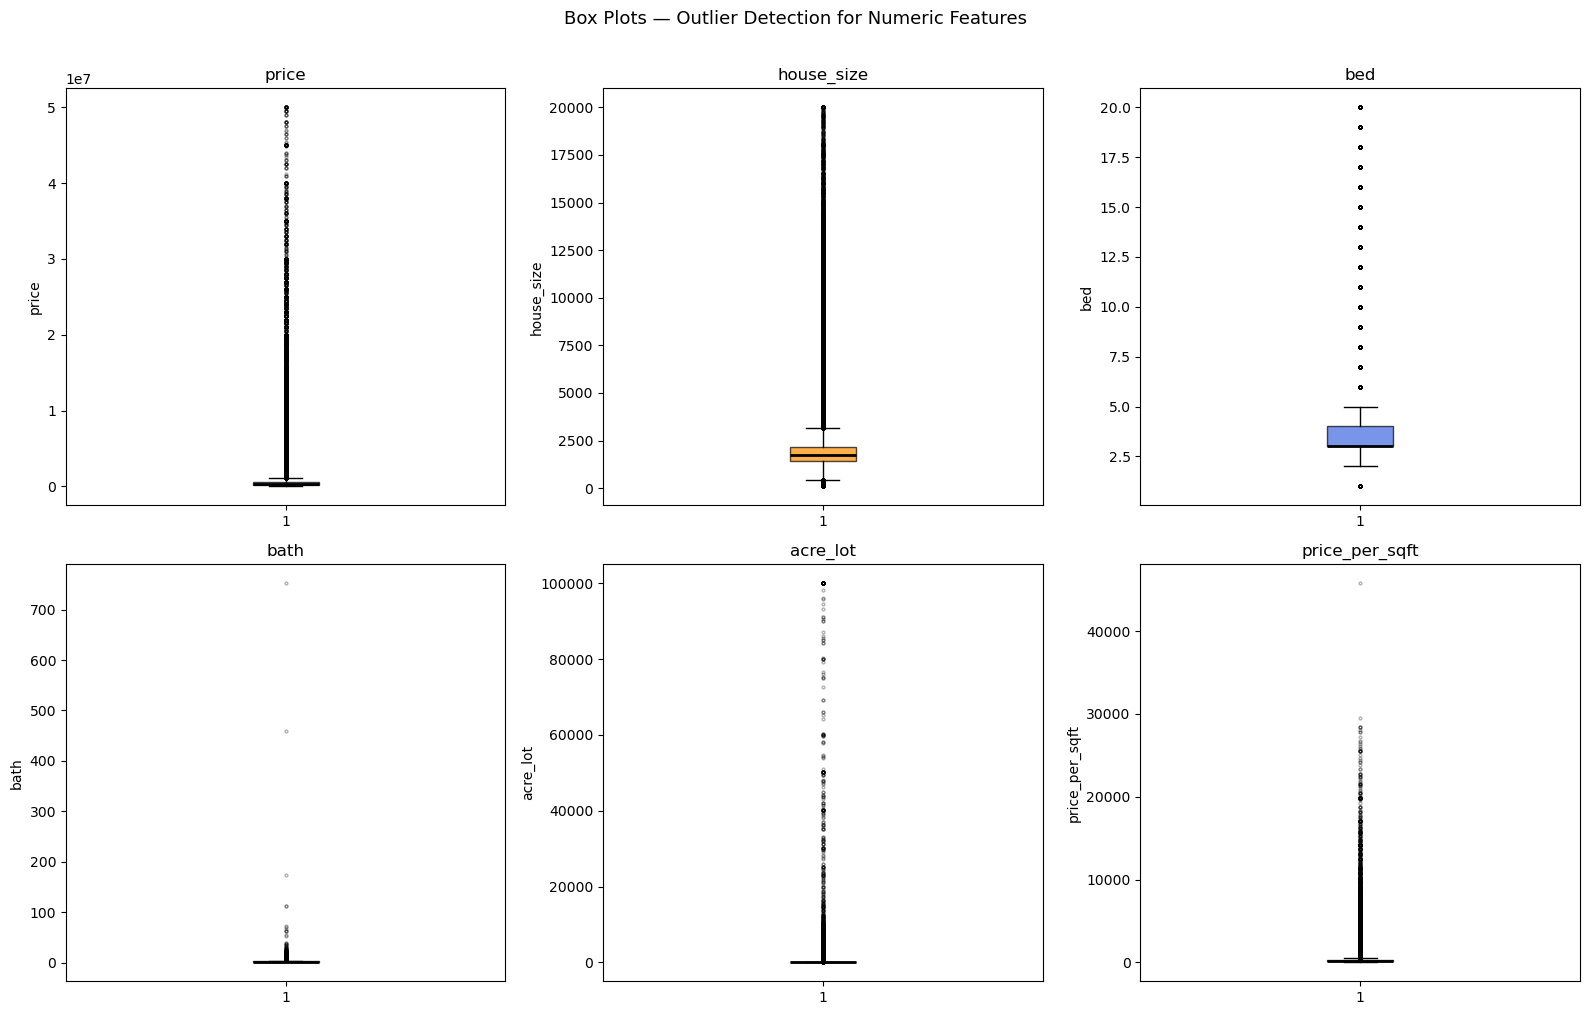

In [354]:
# Box plot comparing For Sale vs Sold listings with clear labels
df_status = df[df['status'].isin(['for_sale', 'sold'])]

for_sale = df_status[df_status['status'] == 'for_sale']['price']
sold = df_status[df_status['status'] == 'sold']['price']

plt.figure(figsize=(8, 6))
box = plt.boxplot([for_sale, sold], labels=['For Sale', 'Sold'], patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
box['boxes'][0].set_facecolor('steelblue')
box['boxes'][1].set_facecolor('darkorange')

plt.ylabel('Listing Price ($)')
plt.title('Listing Price: For Sale vs Sold')
plt.ylim(0, 1_500_000)
plt.tight_layout()
plt.show()

print("Median price For Sale: $", f"{for_sale.median():,.0f}")
print("Median price Sold:     $", f"{sold.median():,.0f}")

The box plot shows that For Sale and Sold listings have similar median prices, but For Sale listings have a slightly higher median and more high-priced outliers. This makes sense because sellers often list at higher asking prices than the final sold price. The capped y-axis at $1.5M keeps the chart readable by hiding the extreme luxury outliers.

## 9. Final Dataset Summary

I display the final information about my cleaned and merged dataset to confirm it is ready for the modeling phase.

In [356]:
print(df.info())
print("
Final shape:", df.shape)
print("
Columns:", df.columns.tolist())

SyntaxError: unterminated string literal (detected at line 2) (3696356737.py, line 2)

In [ ]:
print("Missing values in final dataset:")
print(df.isnull().sum())

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.to_csv('realtor_cleaned_merged.csv', index=False)
print(f"Saved: realtor_cleaned_merged.csv")
print(f"Shape: {df.shape}")

The cleaned and merged dataset is saved as realtor_cleaned_merged.csv and is ready for modeling. It has all the original listing columns plus the three derived features I created and the four Census economic columns joined by ZIP code.

## 10. Conclusion

I completed data wrangling and exploratory data analysis for my USA Real Estate Market Analysis capstone project.
I loaded 2.2 million residential listings from Realtor.com and two ACS Census tables covering over 33,000 ZIP codes. I cleaned the realtor data by dropping rows missing price, state and ZIP code, filling bed, bath, house_size and acre_lot with state-level medians, removing duplicates, and filtering out implausible prices and sizes. I extracted median household income, unemployment rate, poverty rate and occupied units from the Census tables and joined them to the listings by ZIP code.
I created three new features: price per square foot, bed-to-bath ratio and listing count per ZIP code.
Key findings from EDA:
- Price is heavily right skewed with a median around $325,000. Log transformation makes it suitable for regression modeling.
- House size and bathroom count have the strongest correlations with price among property features.
- ZIP code median household income is a strong predictor — wealthier ZIP codes have significantly higher listing prices.
- California, Hawaii and Massachusetts have the highest median prices and price per square foot. Florida, California and Texas dominate by listing volume.
- Bedroom and bathroom count show clear positive relationships with price.
- Bed, bath and house_size are correlated with each other which I will address with regularization in the modeling phase.
The cleaned dataset is saved and ready for the next step which is building and evaluating regression models to predict listing price.

- include what you learned from data